In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import warnings
from scipy.cluster import hierarchy
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')
try:
    import seaborn as sns
except ImportError:
    print("seaborn no instalada")

# Análisis Exploratorio

In [20]:
df = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/mall_customers.csv')
df.head(5)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Verificamos si hay valores nulos para imputar

In [21]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# Escalamos las Variables

In [22]:
scaler_X = StandardScaler(with_mean=True, with_std=True)
scaler_X.fit(df.iloc[:,2:5])
X = pd.DataFrame(scaler_X.transform(df.iloc[:,2:5],), columns = df.iloc[:,2:5].columns )

# KMeans

Text(0, 0.5, 'wcss: sum of dist. of sample to their closest cluster center')

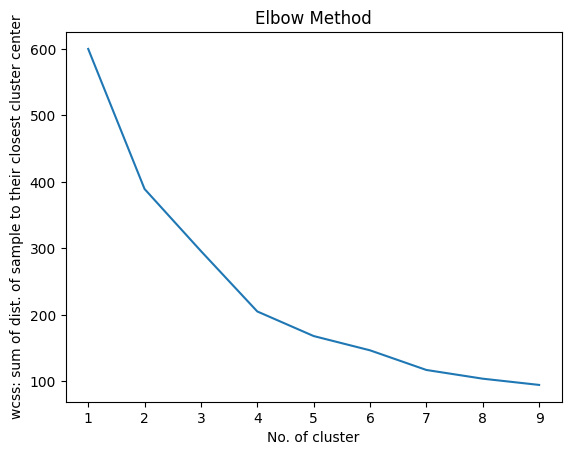

In [23]:
wcss=[]
for i in range(1,10):
    kmeans=KMeans(n_clusters=i,init='k-means++',)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,10),wcss)
plt.title('Elbow Method')
plt.xlabel('No. of cluster')
plt.ylabel('wcss: sum of dist. of sample to their closest cluster center' )

In [24]:
kmeans_1=KMeans(n_clusters=5)
kmeans_1.fit(X)
cluster_pred=kmeans_1.predict(X)

<Axes: xlabel='Spending Score (1-100)', ylabel='Annual Income (k$)'>

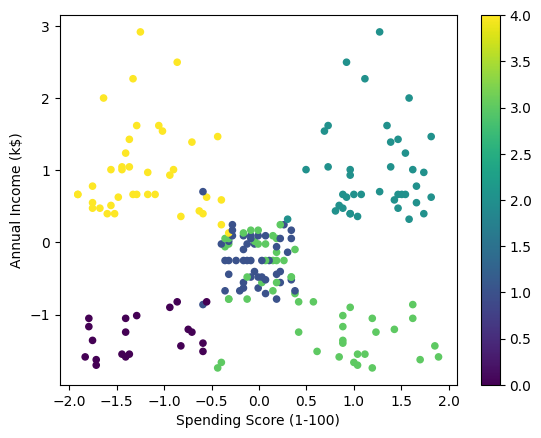

In [25]:
X.plot(x='Spending Score (1-100)', y='Annual Income (k$)',kind='scatter',c=cluster_pred,colormap='viridis')

# DBSCAN

In [26]:
dbscan_1 = DBSCAN(eps=0.5, min_samples=5)
dbscan_1.fit(X)
cluster_pred_2 = dbscan_1.labels_.astype(int)

<Axes: xlabel='Spending Score (1-100)', ylabel='Annual Income (k$)'>

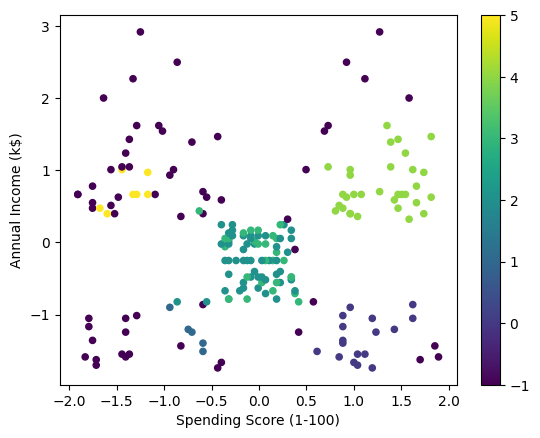

In [27]:
X.plot(x='Spending Score (1-100)', y='Annual Income (k$)',kind='scatter',c=cluster_pred_2,colormap='viridis')

# PCA

In [28]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [29]:
pca.components_[0]

array([ 0.70638235, -0.04802398, -0.70619946])

In [30]:
kmeans_2=KMeans(n_clusters=5)
kmeans_2.fit(X_pca[:,0:1])
cluster_pred_3=kmeans_2.predict(X_pca[:,0:1])

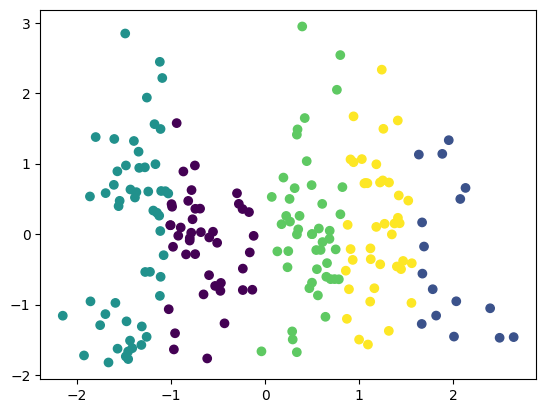

In [31]:
plt.scatter(X_pca[:,0],X_pca[:,1],c=cluster_pred_3,cmap='viridis')

<Axes: xlabel='Spending Score (1-100)', ylabel='Annual Income (k$)'>

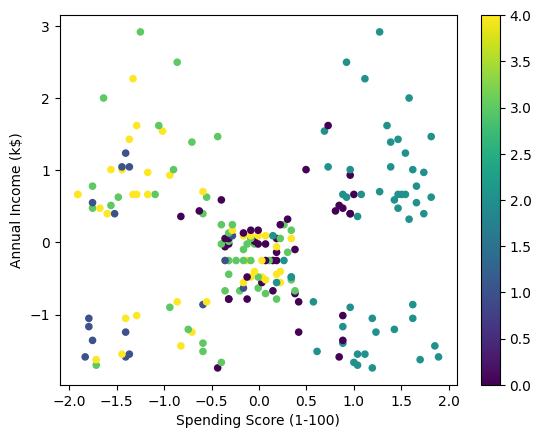

In [32]:
X.plot(x='Spending Score (1-100)', y='Annual Income (k$)',kind='scatter',c=cluster_pred_3,colormap='viridis')

# Clustering Jerarquico

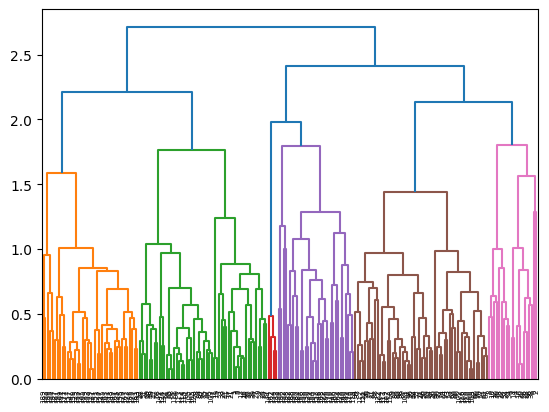

In [33]:
linkage = hierarchy.linkage(X, method='average')
cluster_pred_4 = hierarchy.fcluster(linkage, 10 , criterion='maxclust')
dendro=hierarchy.dendrogram( linkage )

<Axes: xlabel='Spending Score (1-100)', ylabel='Annual Income (k$)'>

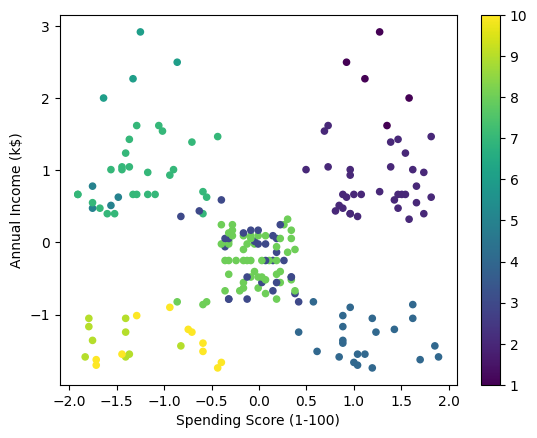

In [34]:
X.plot(x='Spending Score (1-100)', y='Annual Income (k$)',kind='scatter',c=cluster_pred_4,colormap='viridis')

# Ejercicios

Pensar las respuestas y despues probar en el código

* [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
* [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html)
* [fcluster](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.fcluster.html#scipy.cluster.hierarchy.fcluster)

## 1 - Según el método de Elbow ¿Que otro K podria haber sido bueno para kmeans?

Según el método Elbow, además de K=5 podrían ser razonables K=3 o K=4 dependiendo de dónde se observe la "rodilla" en la gráfica; K=3 agruparía en macro-segmentos (bajo/medio/alto gasto), K=4 podría separar un segmento intermedio.

## 2 - ¿Que pasa si reduzco min_samples en DBSCAN?

Si reduzco `min_samples` en DBSCAN: se reducirán las exigencias para que un punto forme un núcleo, por lo que habrá menos ruido (-1) y potencialmente más clusters pequeños. Si lo aumento, habrá más puntos marcados como ruido y menos clusters.

## 3 - Usando ``pca.components_[0]`` ¿Podriamos "entender" que representa la primera componente de PCA / escribir la formula para calcularlo?

`pca.components_[0]` contiene los coeficientes (loadings) de la primera componente principal. Si llamamos a las variables estandarizadas z1,z2,z3 y los coeficientes w1,w2,w3, la primera componente vale:

$$\text{PC}_1 = w_1\cdot z_1 + w_2\cdot z_2 + w_3\cdot z_3$$

Y la proyección de una observación estandarizada x es `x @ w` (producto punto). Los signos y magnitudes de w nos dicen qué variables contribuyen más.

## 4 - ¿Que pasa si uso otro metodo de asociacion para el linkage del clustering jerárquico?

Cambiar el método de `linkage` (p. ej. `single`, `complete`, `average`, `ward`) modifica la forma de los clusters: `single` tiende a crear cadenas, `complete` produce clusters compactos, `ward` minimiza la varianza intra-cluster y suele funcionar bien con variables continuas.

## 5 - ¿Cómo hago los clusters del clustering jerarquico (``fcluster``) por distancia y no por numero maximo de clusters?

Para usar `fcluster` por distancia en vez de número máximo de clusters, usar `criterion='distance'` y fijar un umbral `t` (p. ej. `fcluster(linkage, t=5, criterion='distance')`).

Experimentos adicionales y reproducibilidad

In [35]:
RANDOM_STATE = 42

Elbow con random_state y n_init para reproducibilidad

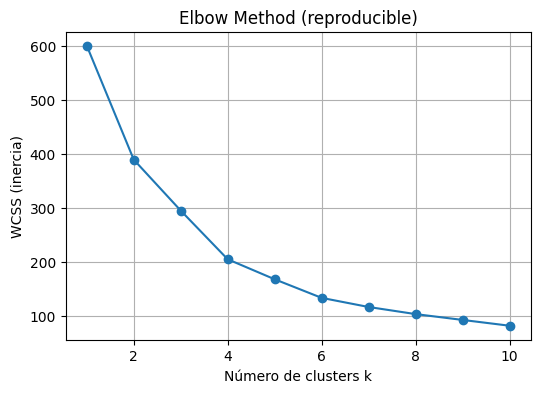

In [36]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method (reproducible)')
plt.xlabel('Número de clusters k')
plt.ylabel('WCSS (inercia)')
plt.grid(True)
plt.show()

Probar KMeans con k=4 (alternativa razonable) y mostrar tamaños

Tamaños de clusters KMeans k=4: [65 40 57 38]


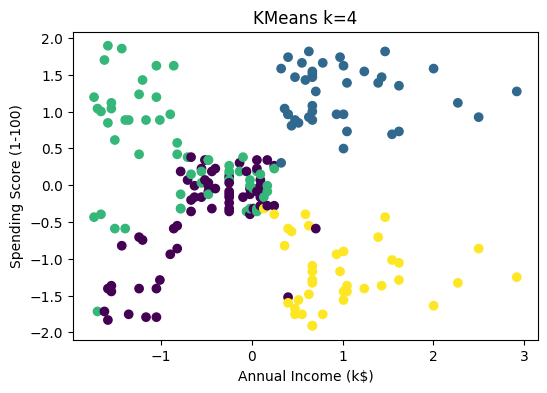

In [37]:
kmeans4 = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
labels_k4 = kmeans4.fit_predict(X)
print('Tamaños de clusters KMeans k=4:', np.bincount(labels_k4))
plt.figure(figsize=(6,4))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c=labels_k4, cmap='viridis')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('KMeans k=4')
plt.show()

Experimentos con DBSCAN variando min_samples

DBSCAN min_samples=3: clusters=8, noise=32


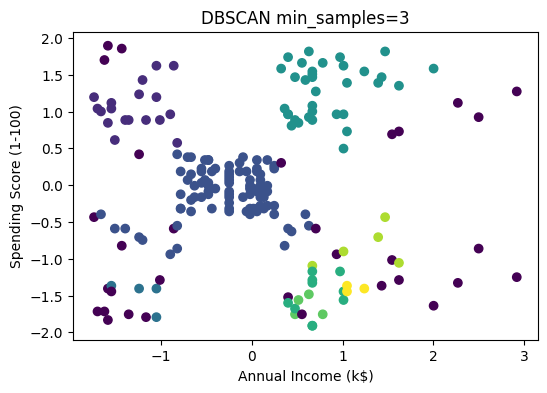

DBSCAN min_samples=5: clusters=6, noise=60


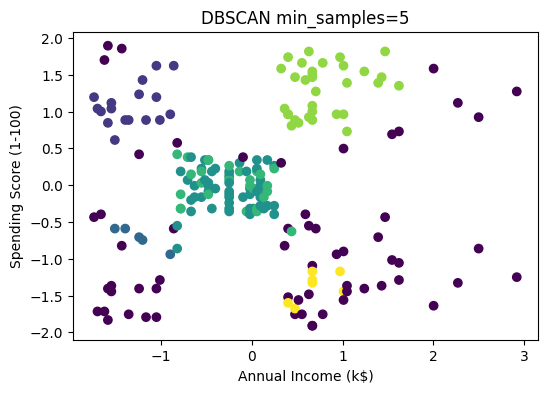

DBSCAN min_samples=8: clusters=5, noise=92


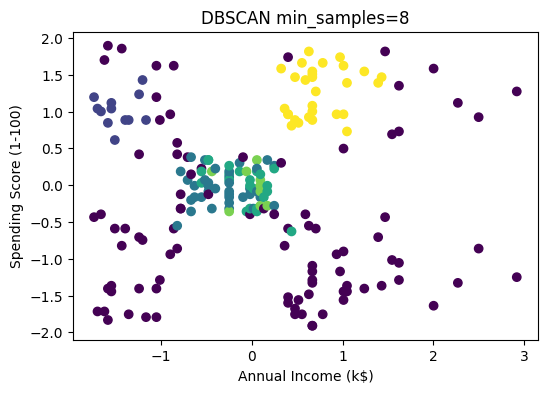

In [38]:
for ms in (3, 5, 8):
    db = DBSCAN(eps=0.5, min_samples=ms)
    lab = db.fit_predict(X)
    n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
    n_noise = np.sum(lab == -1)
    print(f'DBSCAN min_samples={ms}: clusters={n_clusters}, noise={n_noise}')
    plt.figure(figsize=(6,4))
    plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c=lab, cmap='viridis')
    plt.title(f'DBSCAN min_samples={ms}')
    plt.xlabel('Annual Income (k$)')
    plt.ylabel('Spending Score (1-100)')
    plt.show()

PCA: cargar componentes y comprobar fórmula

In [39]:
pca_check = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_check = pca_check.fit_transform(X)
print('PC1 loadings (componentes):', pca_check.components_[0])
print('Verificación: la proyección PC1 coincide con X @ components_[0]?:',
      np.allclose(X_pca_check[:,0], X.values.dot(pca_check.components_[0])))

PC1 loadings (componentes): [ 0.70638235 -0.04802398 -0.70619946]
Verificación: la proyección PC1 coincide con X @ components_[0]?: True


Clustering jerárquico: usar fcluster por distancia

Número de clusters usando threshold distance t=5: 1


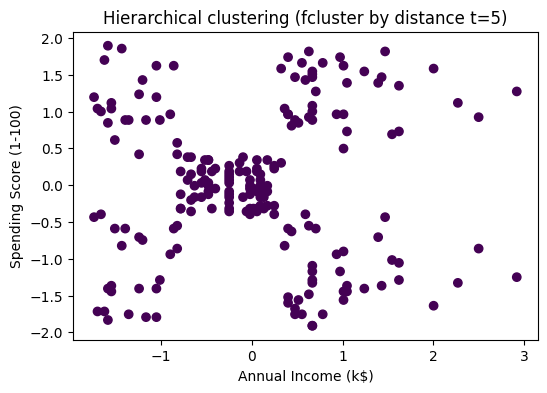

In [40]:
link = hierarchy.linkage(X, method='average')
labels_by_distance = hierarchy.fcluster(link, t=5, criterion='distance')
print('Número de clusters usando threshold distance t=5:', len(np.unique(labels_by_distance)))
plt.figure(figsize=(6,4))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c=labels_by_distance, cmap='viridis')
plt.title('Hierarchical clustering (fcluster by distance t=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()